<a href="https://colab.research.google.com/github/pacheco110798/WalmartSalesAnalysis/blob/main/walmart_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MEMORIA ORIGINAL
train: 33.77 MB
stores: 0.00 MB
features: 1.09 MB

MEMORIA OPTIMIZADA
train: 5.23 MB
stores: 0.00 MB
features: 0.47 MB
MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64
MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64


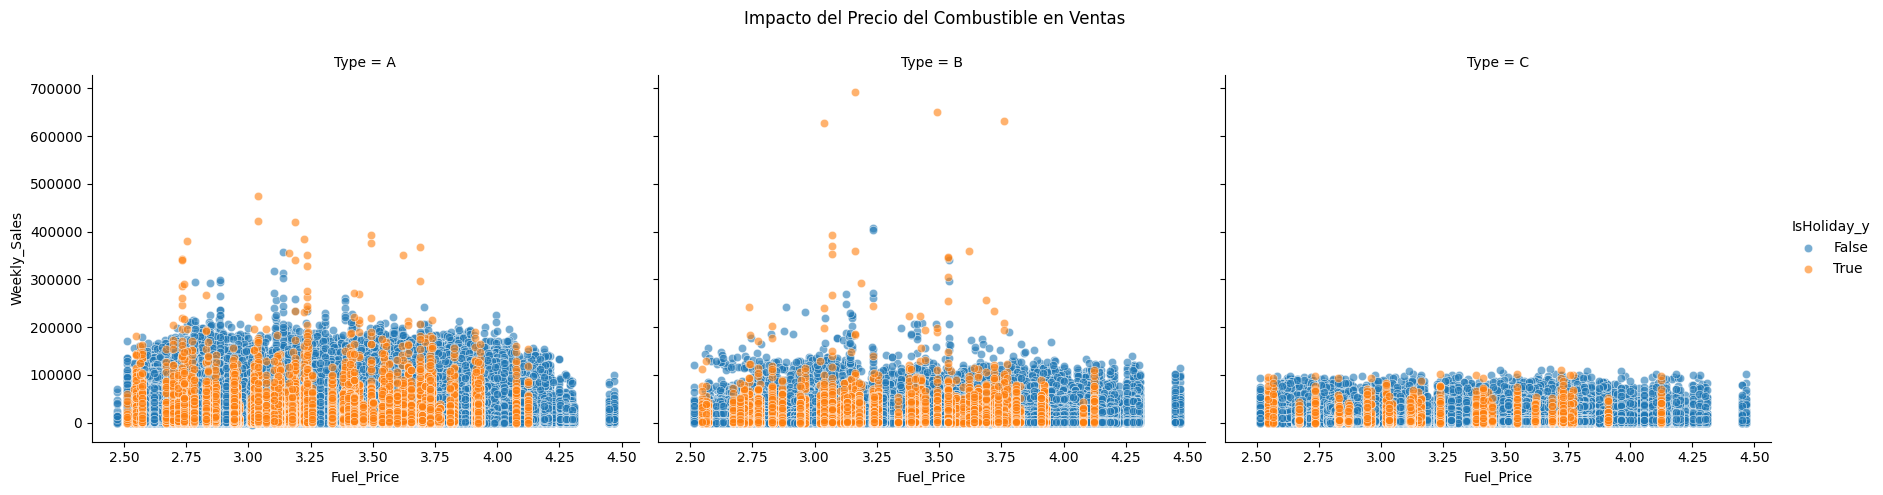

      % Outperformer
Type                
A              74.57
B              74.31
C              73.55


/tmp/ipykernel_40182/3501427449.py:193: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_features = pd.read_csv("features.csv")
df_stores = pd.read_csv("stores.csv")
df_test = pd.read_csv("test.csv")
df_train = pd.read_csv("train.csv")

def downcast(df):

    for col in df.columns:

        col_type = df[col].dtype

        if col_type == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')

        elif col_type == 'float64':
            df[col] = pd.to_numeric(df[col], downcast='float')

        elif col_type == 'object':

            num_unique = df[col].nunique()
            num_total = len(df[col])

            # Convertir a category si tiene baja cardinalidad
            if num_unique / num_total < 0.5:
                df[col] = df[col].astype('category')

    return df

print("MEMORIA ORIGINAL")

for name, df in zip(
    ["train", "stores", "features"],
    [df_train, df_stores, df_features]
):
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{name}: {mem:.2f} MB")

# Aplicar downcasting
df_train = downcast(df_train)
df_stores = downcast(df_stores)
df_features = downcast(df_features)


df_train["Date"] = pd.to_datetime(df_train["Date"])
df_features["Date"] = pd.to_datetime(df_features["Date"])

print("\nMEMORIA OPTIMIZADA")

for name, df in zip(
    ["train", "stores", "features"],
    [df_train, df_stores, df_features]
):
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{name}: {mem:.2f} MB")


master_df["Date"] = pd.to_datetime(master_df["Date"])

master_df = df_train.merge(
    df_stores,
    on="Store",
    how="left"
)

master_df = master_df.merge(
    df_features,
    on=["Store", "Date"],
    how="left"
)
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

# Revisar nulos
print(master_df[markdown_cols].isnull().sum())
master_df[markdown_cols] = master_df[markdown_cols].fillna(0)
print(master_df[markdown_cols].isnull().sum())

#Extraer fechas

master_df["Date"] = pd.to_datetime(master_df["Date"])

master_df["Year"] = master_df["Date"].dt.year.astype("int16")

master_df["Month"] = master_df["Date"].dt.month.astype("int8")

master_df["Week"] = (
    master_df["Date"]
    .dt.isocalendar()
    .week
    .astype("int8")
)

master_df["Quarter"] = (
    master_df["Date"]
    .dt.quarter
    .astype("int8")
)

master_df = master_df.sort_values(
    by=["Store", "Dept", "Date"]
)

# master_df["Venta_Semana"] = (
#     master_df
#     .groupby(["Store", "Dept"])["Weekly_Sales"]
#     .shift(0)
# )

master_df["Venta_Semana_Anterior"] = (
    master_df
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .shift(1)
)

g = sns.FacetGrid(
    data=master_df,
    col="Type",
    hue="IsHoliday_y",
    height=5,
    aspect=1.2
)

g.map(
    sns.scatterplot,
    "Fuel_Price",
    "Weekly_Sales",
    alpha=0.6
)

g.add_legend()

plt.subplots_adjust(top=0.85)

g.fig.suptitle(
    "Impacto del Precio del Combustible en Ventas"
)

plt.show()

## temporary df to calculate aavg sales
store_avg = (
    master_df
    .groupby("Store")["Weekly_Sales"]
    .mean()
    .rename("Store_Avg_Sales")
)

## merge new feature into df
master_df = master_df.merge(
    store_avg,
    on="Store",
    how="left"
)

master_df = master_df.sort_values(
    by=["Store", "Dept", "Date"]
)

master_df["Sales_Last_Year"] = (
    master_df
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .shift(52)
)

master_df["Sales_Last_Year"] = master_df["Sales_Last_Year"].fillna(0)

master_df["Performance"] = np.where(
    master_df["Weekly_Sales"] >
    master_df["Sales_Last_Year"],
    "Outperformer",
    "Underperformer"
)

holiday_df = master_df[
    master_df["IsHoliday_y"] == True
].copy()

holiday_df["Outperformer_Flag"] = np.where(
    holiday_df["Performance"] == "Outperformer",
    1,
    0
)

pivot = pd.pivot_table(
    holiday_df,
    values="Outperformer_Flag",
    index="Type",
    aggfunc="mean"
)

pivot = pivot * 100

pivot.columns = ["% Outperformer"]

print(pivot.round(2))